In [1]:
import sys
sys.path.append('/root/c/d/puceng/')
from src.models.puceng_module import PUCENGLitModule
import torch
from pathlib import Path
from joblib import dump, load
model_path = '/root/c/d/puceng/logs/new/train/runs/2025-02-24_15-18-09/checkpoints/epoch_089.ckpt'
data_folder = '/root/c/d/puceng/data/puceng/j3.4_IL_10_IL_40/'
enc = load('/root/c/d/puceng/notebooks/data/one_hot_encoder_20.joblib')

In [2]:
model =  PUCENGLitModule.load_from_checkpoint(model_path).eval() 
exts = ['xlsx']
paths_top = [p for ext in exts for p in Path(f'{data_folder}').glob(f'**/*.{ext}')]
import tqdm
import pandas as pd
import numpy as np
y = []
x = []

for i in tqdm.tqdm(paths_top[:1]):
    writer_1 = pd.ExcelFile(i)
    for i in writer_1.sheet_names:
        data_frame = writer_1.parse(i,header=None)
        x.append((data_frame[0][:20]).astype('int')) # 直接读取1，2，3   # 20维度的话 x.append((data_frame[0][:20]).astype('int'))
        y.append(data_frame[2])                      # 直接读取预测值 

y_arr = np.array(y)
x_arr = np.array(x)

/root/miniconda3/envs/puceng/lib/python3.9/site-packages/lightning/pytorch/utilities/parsing.py:199: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
100%|██████████| 1/1 [00:01<00:00,  1.88s/it]


In [3]:
x = torch.tensor(enc.transform(x_arr)).float()
pred=model.net.forward(x.cuda()).cpu().detach().numpy()

In [4]:
def compute_NRMSE(y_true, y_pred):
    return np.sqrt(np.sum(np.square(y_pred - y_true))/np.sum(np.square(y_true)))
def plot(y_pred,y):
    import matplotlib.pyplot as plt 
    fig, ax=plt.subplots()

    plt.plot(np.linspace(0.2,1.2,1049), y, label='Target',color='red')
    plt.xlabel('Frequency (THz)')
    plt.ylabel('S11 (dB)')
    NRMSE = round(compute_NRMSE(y, y_pred   )*100,1)

    plt.plot(np.linspace(0.2,1.2,1049),   y_pred,   label=f'Forward({NRMSE}%)',color='green' )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.legend(frameon=False)

In [5]:
y_arr[0].shape

(1049,)

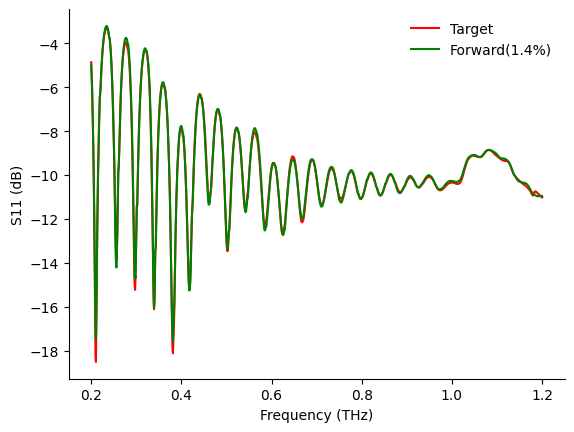

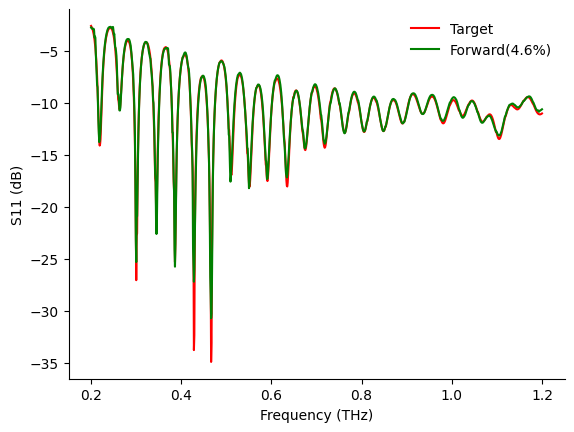

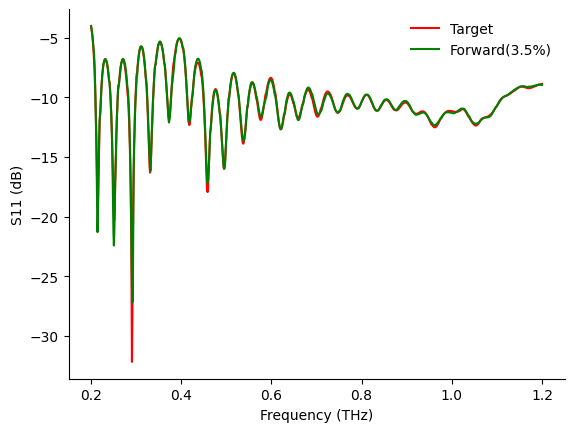

In [6]:
for i in range(-4,-1):
    plot(pred[i], y_arr[i]) # 可视化第111条数据

#  单个样本

In [7]:
x_arr[0]
y_true = y_arr[0]

In [8]:
import numpy as np
x_test = [3, 2, 3, 3, 1, 3, 2, 2, 3, 2, 1, 2, 1, 2, 1, 1, 3, 3, 1, 2] 
x_0 = enc.transform([x_test])

In [9]:
sample = torch.tensor(x_0,dtype=torch.float32)
y_pred = model.net.forward(sample.cuda()).cpu().detach().squeeze().numpy()

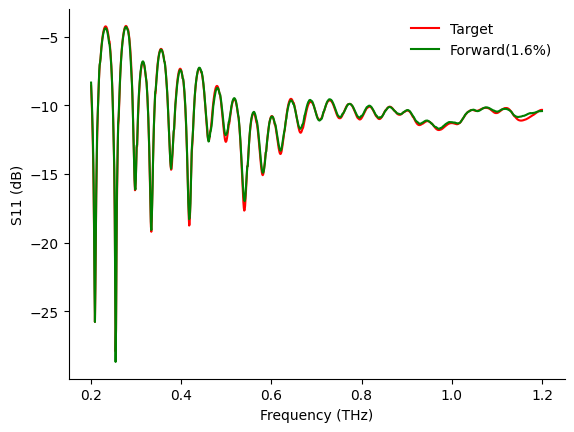

In [10]:
plot(y_pred,y_true)
